# Gradient Descent: From Manual calculations to Python code

We are converting **every single step** from the manual calculations of gradient descent into executable python code.

**Data points** (x=1, y=3) and (x=3, y=6)

**Initial:** m = -1, b = 1, learning rate α = 0.1, n = 2

We will now implement **exactly** the same steps in Python code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize # Optimization library for m/b

# DATA
x = np.array([1.0, 3.0])
y = np.array([3.0, 6.0])
n = len(x)

# INITIAL VALUES MATCHING MANUAL WORK
m = -1.0
b = 1.0
alpha = 0.1
num_iterations = 4

# LISTS TO TRACK HISTORY FOR PLOTTING
m_history = [m]
b_history = [b]
mse_history = []                  #Mean Squared Error
offset_history = []               # "Total Error offset" = sum(ŷ - y)

print("====== STARTING GRADIENT DESCENT ======")

# THE GRADIENT DESCENT LOOP
for i in range (num_iterations):
    print(f"\n{'='*60}")
    print(f"ITERATION{i+1} (using current m={m:.4f}, b={b:.4f})")
    print(f"{'='*60}")

    # Step A: Compute predictions ŷ
    yhat = m * x + b
    print("\nStep A → Predictions ŷ:")
    print(f"   for x=1 → ŷ1 = {yhat[0]:.4f}")
    print(f"   for x=3 → ŷ2 = {yhat[1]:.4f}")

    # Step B: Compute errors (ŷ - y)
    errors = y - yhat
    print("\nStep B → Errors (ŷ - y):")
    print(f"   Error 1: {errors[0]:.4f}")
    print(f"   Error 2: {errors[1]:.4f}")

    # Gradients
    grad_m = - (2 / n) * np.sum(x * errors)
    grad_b = - (2 / n) * np.sum(errors)
    print("\nStep C → Gradients:")
    print(f"   ∂J/∂m = {grad_m:.4f}")
    print(f"   ∂J/∂b = {grad_b:.4f}")

    # Update rule
    m_new = m - alpha * grad_m
    b_new = b - alpha * grad_b
    print("\nStep D → Updated parameters:")
    print(f"   New m = {m_new:.4f}")
    print(f"   New b = {b_new:.4f}")

    # Record for plots and summary
    mse = np.mean(errors ** 2)
    offset = np.sum(yhat - y)
    mse_history.append(mse)
    offset_history.append(offset)

    # Move to next iteration
    m = m_new
    b = b_new
    m_history.append(m)
    b_history.append(b)

print("\n" + "="*60)
print("FINISHED 4 ITERATIONS")
print(f"Final m = {m:.4f}, b = {b:.4f}")

# FINAL PREDICTIONS
final_yhat = m * x + b
print("\nFinal predictions with learned m and b:")
print(f"   ŷ(1) = {final_yhat[0]:.4f} (target = 3)")
print(f"   ŷ(3) = {final_yhat[1]:.4f} (target = 6)")

====== STARTING GRADIENT DESCENT ======

ITERATION1 (using current m=-1.0000, b=1.0000)

Step A → Predictions ŷ:
   for x=1 → ŷ1 = 0.0000
   for x=3 → ŷ2 = -2.0000

Step B → Errors (ŷ - y):
   Error 1: 3.0000
   Error 2: 8.0000

Step C → Gradients:
   ∂J/∂m = -27.0000
   ∂J/∂b = -11.0000

Step D → Updated parameters:
   New m = 1.7000
   New b = 2.1000

ITERATION2 (using current m=1.7000, b=2.1000)

Step A → Predictions ŷ:
   for x=1 → ŷ1 = 3.8000
   for x=3 → ŷ2 = 7.2000

Step B → Errors (ŷ - y):
   Error 1: -0.8000
   Error 2: -1.2000

Step C → Gradients:
   ∂J/∂m = 4.4000
   ∂J/∂b = 2.0000

Step D → Updated parameters:
   New m = 1.2600
   New b = 1.9000

ITERATION3 (using current m=1.2600, b=1.9000)

Step A → Predictions ŷ:
   for x=1 → ŷ1 = 3.1600
   for x=3 → ŷ2 = 5.6800

Step B → Errors (ŷ - y):
   Error 1: -0.1600
   Error 2: 0.3200

Step C → Gradients:
   ∂J/∂m = -0.8000
   ∂J/∂b = -0.1600

Step D → Updated parameters:
   New m = 1.3400
   New b = 1.9160

ITERATION4 (using cur

In [2]:
# Use Scipy to optimize for the TRUE best m and b for comparison
def mse_loss_function(params):
    m_opt, b_opt = params
    yhat_opt = m_opt * x + b_opt
    return np.mean((y - yhat_opt)**2)

result = minimize(mse_loss_function, [-1.0, 1.0], method='BFGS')

print("Scipy optimal solution:")
print(f"   Optimal m = {result.x[0]:.4f}")
print(f"   Optimal b = {result.x[1]:.4f}")
print(f"   Minimal MSE = {result.fun:.6f}")

Scipy optimal solution:
   Optimal m = 1.5000
   Optimal b = 1.5000
   Minimal MSE = 0.000000


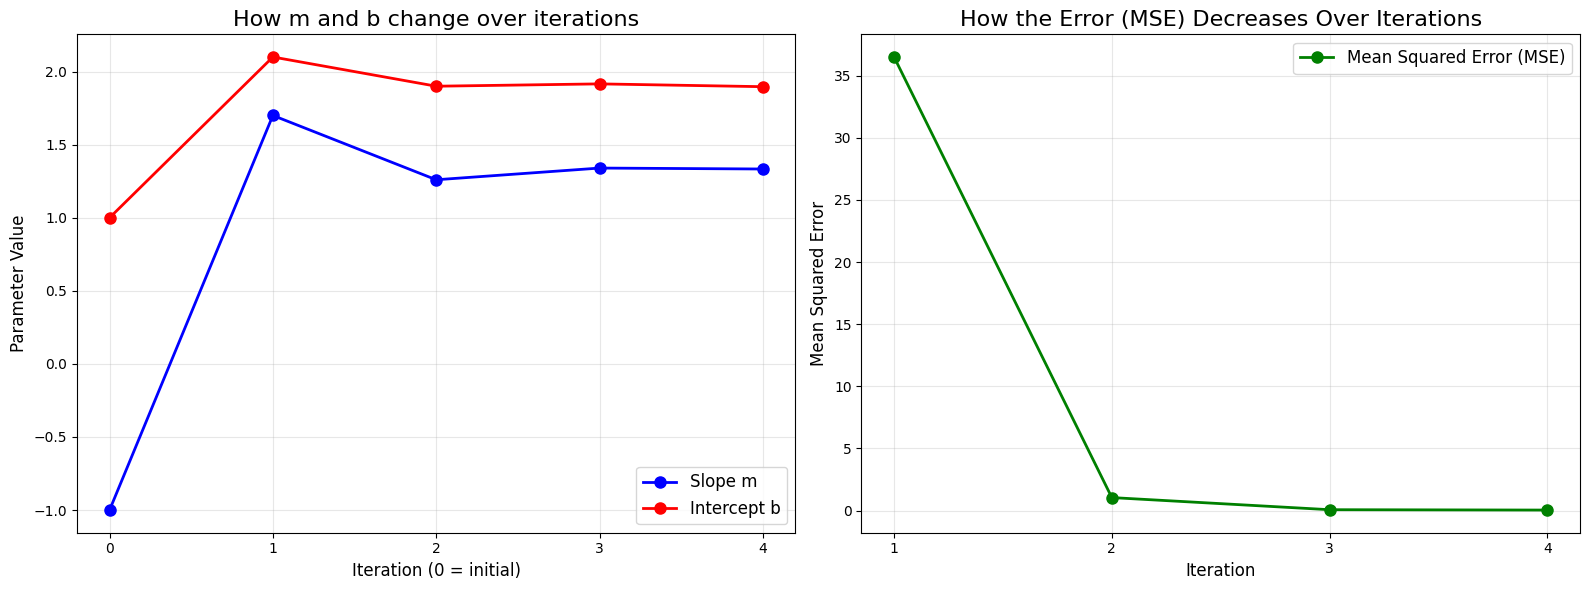

Side-by-side plots created successfully.
m & b use iterations: [0, 1, 2, 3, 4]
MSE uses iterations:  [1, 2, 3, 4]


In [9]:
# PLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: m and b over iterations
iterations = range(len(m_history))
ax1.plot(iterations, m_history, 'b-o', linewidth=2, markersize=8, label='Slope m')
ax1.plot(iterations, b_history, 'r-o', linewidth=2, markersize=8, label='Intercept b')
ax1.set_title('How m and b change over iterations', fontsize=16)
ax1.set_xlabel('Iteration (0 = initial)', fontsize=12)
ax1.set_ylabel('Parameter Value', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)
ax1.set_xticks(iterations)

# PLOT 2: Error (MSE) over iterations
iterations_mse = range(1, len(m_history)) 
ax2.plot(iterations_mse, mse_history, 'g-o', linewidth=2, markersize=8,
         label='Mean Squared Error (MSE)')
ax2.set_title('How the Error (MSE) Decreases Over Iterations', fontsize=16)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)
ax2.set_xticks(iterations_mse)

plt.tight_layout()
plt.show()

print("Side-by-side plots created successfully.")
print(f"m & b use iterations: {list(iterations)}")
print(f"MSE uses iterations:  {list(iterations_mse)}")

In [10]:
import pandas as pd

data = {
    'Iteration': ['Initial'] + [f'{i+1}'for i in range(num_iterations)],
    'm': m_history,
    'b': b_history,
    'Prediction (x=1)': [m_hist * 1 + b_hist for m_hist, b_hist in zip(m_history, b_history)],
    'prediction (x=3)': [m_hist * 3 + b_hist for m_hist, b_hist in zip(m_history, b_history)],
    'Total Error offset (ŷ - y)': offset_history + [np.sum(final_yhat - y)]
}

df = pd.DataFrame(data)
df = df.round(4)
print(df)

  Iteration       m       b  Prediction (x=1)  prediction (x=3)  \
0   Initial -1.0000  1.0000            0.0000           -2.0000   
1         1  1.7000  2.1000            3.8000            7.2000   
2         2  1.2600  1.9000            3.1600            5.6800   
3         3  1.3400  1.9160            3.2560            5.9360   
4         4  1.3336  1.8968            3.2304            5.8976   

   Total Error offset (ŷ - y)  
0                     -11.000  
1                       2.000  
2                      -0.160  
3                       0.192  
4                       0.128  
